In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score,auc
from sklearn.datasets import load_digits, load_breast_cancer
import joblib # 파이썬 객체 저장을 위한 joblib
import tensorflow as tf
from tensorflow.keras import layers, models

# keras 모델 저장 및 로드 기능 사용하기 위한 필요 모듈
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, MaxPooling2D, Flatten, Conv2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist


np.random.seed(42)
tf.random.set_seed(42)

In [14]:
# ======================================
# 1  CIFAR-10 데이터 불러오기
# ======================================

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()
#CIFAR-10 이미지는 32 x 32 크기의 컬러 이미지고, 10개 클래스로 구성
# y 데이터(배치,1) 형태기 때문애 reshape 필요

y_train = y_train.reshape(-1)
y_test = y_test.reshape(-1)

In [15]:
# ======================================
# 3. 데이터 정규화
# ======================================

X_train = X_train / 255.0
X_test = X_test / 255.0

In [16]:
# ======================================
# 4. 시각화 위한 클래스 이름 정의
# ======================================

# 클래스 이름 정의
class_names = [
    'Airplane', 'Automobile',"Bird","Cat","Deer","Dog",'Frog',"Horse","Ship","Truck"
]


In [17]:
# ======================================
# 5. 데이터 증강 (Data Augmentation) 정의
# ======================================
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
    ]
)

In [19]:
# ======================================
# 6.  CNN + Dropout 모듈
# ======================================

model = models.Sequential([
    # 첫 번째 CNN layer (돋보기 크기와 이미지 크기 추가!)
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.5),

    # 두 번째 CNN layer (돋보기 크기 추가!)
    layers.Conv2D(32, kernel_size=(3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.5),

    # 세 번째 CNN layer (돋보기 크기 추가!)
    layers.Conv2D(32, kernel_size=(3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.5),

    layers.Flatten(),
    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    # 출력층
    layers.Dense(10, activation='softmax')
])

D:\anaconda3\envs\analyzer\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
# ======================================
# 7. 모델 컴파일
# ======================================

# 모델 컴파일 설정
model.compile(
    optimizer= "adam",
    loss = "sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [21]:
# ======================================
# 8. 모델 학습
# ======================================

history = model.fit(
    X_train,
    y_train,
    epochs = 15,
    batch_size = 64,
    verbose = 1,
    validation_split = 0.2
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.2973 - loss: 1.9775 - val_accuracy: 0.1656 - val_loss: 2.7924
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.4029 - loss: 1.6191 - val_accuracy: 0.2711 - val_loss: 1.9975
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.4414 - loss: 1.5225 - val_accuracy: 0.2678 - val_loss: 2.0798
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.4643 - loss: 1.4591 - val_accuracy: 0.2645 - val_loss: 2.1916
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.4856 - loss: 1.4156 - val_accuracy: 0.3182 - val_loss: 1.9138
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - accuracy: 0.4997 - loss: 1.3752 - val_accuracy: 0.3210 - val_loss: 1.9545
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.5118 - loss: 1.3461 - val_accuracy: 0.4001 - val_loss: 1.6908
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.5235 - loss: 1.3126 - 

In [23]:
# ======================================
# 9. 테스트 데이터 평가
# ======================================
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

#결과 출력
print("테스트 손실 : ",test_loss )
print("테스트 정확도 : ",test_acc )

테스트 손실 :  1.2672932147979736
테스트 정확도 :  0.5546000003814697


D:\anaconda3\envs\analyzer\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) Arial.
  func(*args, **kwargs)
D:\anaconda3\envs\analyzer\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) Arial.
  func(*args, **kwargs)
D:\anaconda3\envs\analyzer\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) Arial.
  func(*args, **kwargs)
D:\anaconda3\envs\analyzer\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) Arial.
  func(*args, **kwargs)
D:\anaconda3\envs\analyzer\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) Arial.
  func(*args, **kwargs)
D:\anaconda3\envs\analyzer\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 54984 (\N{HANGUL SYLLABLE HUN}

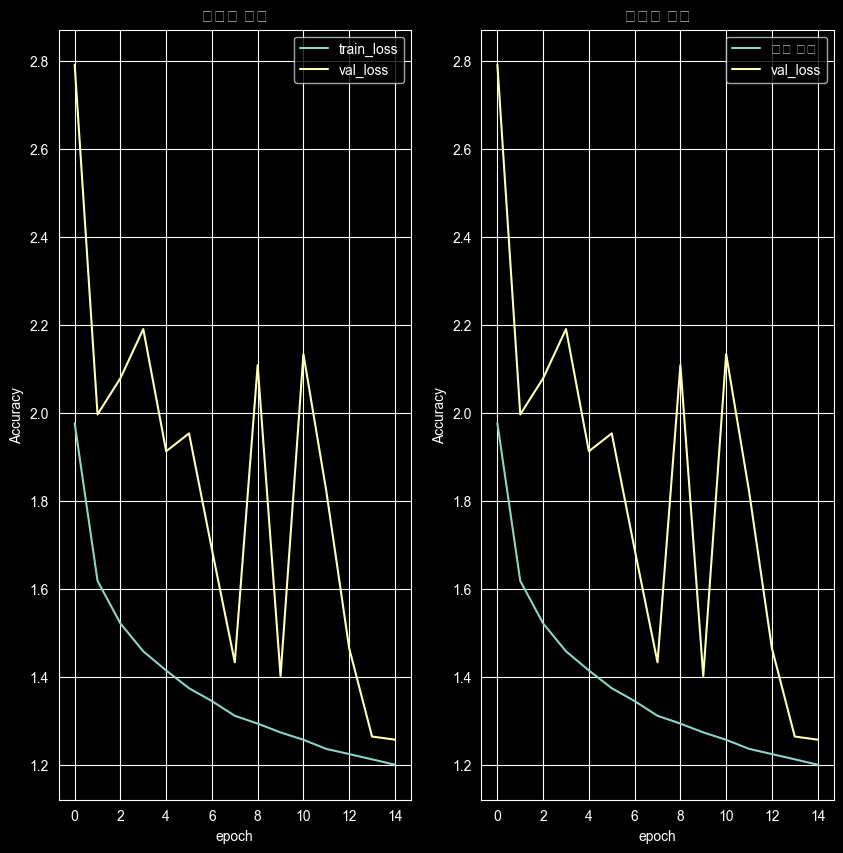

In [24]:
# ======================================
# 10. 학습 곡선 (정확도/손실) 시각화
# ======================================

plt.figure(figsize=(10,10))

# 정확도 그래프
plt.subplot(1,2,1)
plt.plot(history.history['loss'],label = 'train_loss' )
plt.plot(history.history['val_loss'],label = 'val_loss')
plt.title('정확도 변화')
plt.xlabel('epoch')
plt.ylabel('Accuracy')
plt.legend()


# 손실 그래프
plt.subplot(1,2,2)
plt.plot(history.history['loss'],label = '훈련 손실' )
plt.plot(history.history['val_loss'],label = 'val_loss')
plt.title('정확도 변화')
plt.xlabel('epoch')
plt.ylabel('Accuracy')
plt.legend()

In [25]:
# ======================================
# 11. 예측 수행
# ======================================
predictions = model.predict(X_test)
pred_labels = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


NameError: name 'x_test' is not defined

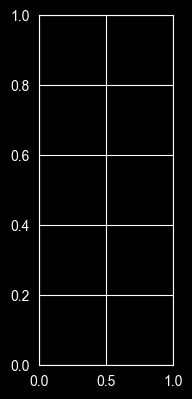

In [26]:
# ======================================
# 12. 앞 10개 이미지 예측 시각화
# ======================================

plt.figure(figsize=(10,10))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i])
    plt.title(f"정답 : {class_names[y_test[i]]}\n예측 : {class_names[pred_labels[i]]}")
    plt.axis("off")
plt.subplot("CIFAR-10 예측 결과", fontsize =16)
plt.show()

# 강사님 git 올려주신 거 확인 해서 수정 필요